Index(['CO2air', 'Cum_irr', 'Tair', 'Tot_PAR', 'Ventwind', 'AssimLight',
       'VentLee', 'HumDef', 'co2_dos', 'PipeGrow', 'EnScr', 'BlackScr',
       'Windsp', 'Winddir', 'Tout', 'Rhout', 'AbsHumOut', 'PARout', 'Iglob',
       'Pyrgeo', 'RadSum'],
      dtype='object')
(47809, 21)
X shape:  (47789, 20, 21)
Y shape:  (47789, 21)


C:\Users\Deni\python\greenhouse\.venv1\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 20, 128)        │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │           693 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,317 (544.21 KB)

 Trainable params: 139,317 (544.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.2848 - mae: 0.3317 - val_loss: 0.1914 - val_mae: 0.2741
Epoch 2/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0586 - mae: 0.1309 - val_loss: 0.1253 - val_mae: 0.2171
Epoch 3/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0430 - mae: 0.1060 - val_loss: 0.1047 - val_mae: 0.1946
Epoch 4/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0357 - mae: 0.0968 - val_loss: 0.0928 - val_mae: 0.1864
Epoch 5/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0352 - mae: 0.0924 - val_loss: 0.0865 - val_mae: 0.1757
Epoch 6/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0321 - mae: 0.0886 - val_loss: 0.0791 - val_mae: 0.1647
Epoch 7/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0292 - mae: 0.0857 - val_loss: 0.0852 - val_mae: 0.1705
Epoch 8/20
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0270 - mae: 0.0827 - val_loss: 0.0874 - val_mae: 0.1780
Epoch 9/20
1046/1046 ━━━

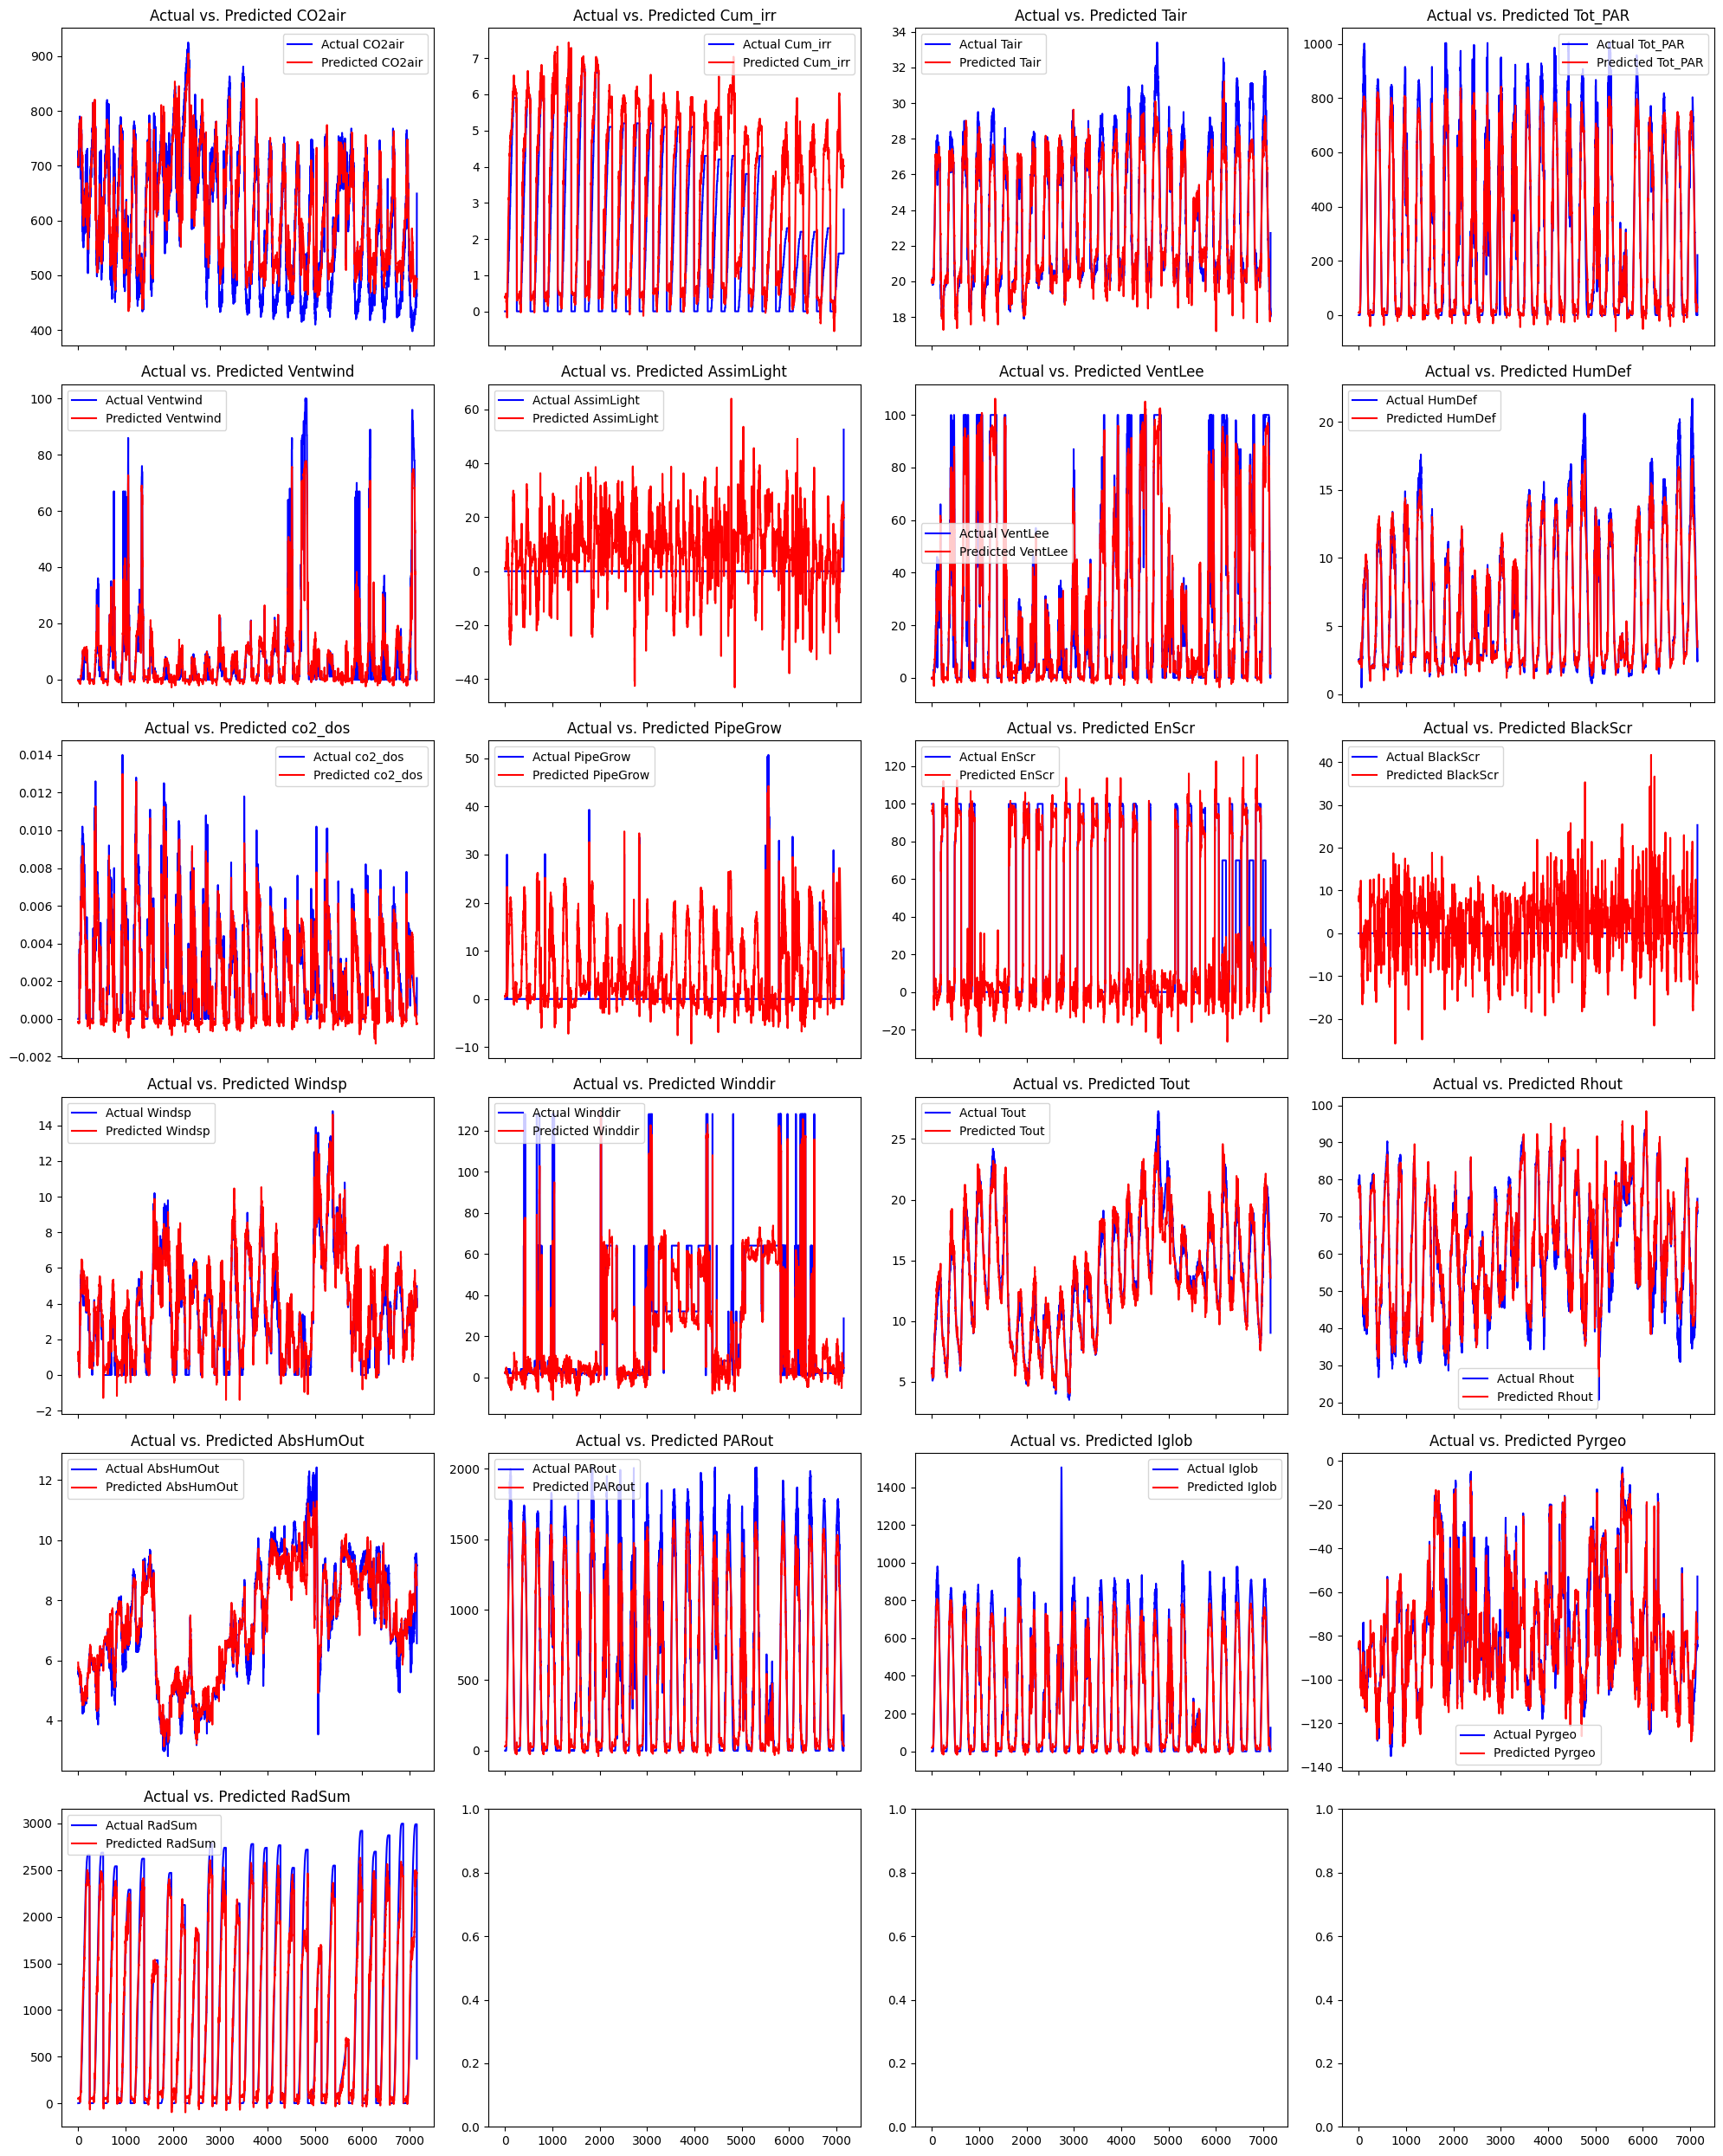

In [10]:
import os
import keras
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import keras.src.utils.config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
tf.compat.v1.logging.set_verbosity('ERROR')
from keras.api.optimizers import Adam
from keras.api.models import Sequential
from keras.api.layers import LSTM, Bidirectional, Dropout
from keras.api.layers import Dense
from keras.api.layers import InputLayer
from keras.api.callbacks import ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.python.keras import layers
import joblib
#from tensorflow.keras.layers import ELU

data = pd.read_csv("GreenhouseClimate.csv", low_memory=False)
data.index = data['%time']

data = data.apply(pd.to_numeric, errors='coerce')

weatherData = pd.read_csv("Weather.csv")
weatherData.index = weatherData['%time']
weatherData = weatherData.apply(pd.to_numeric, errors='coerce')

#Greenhouse climate file data
testData = pd.DataFrame(index=data.index.copy())
testData['CO2air'] = data['CO2air'].copy()
testData['Cum_irr'] = data['Cum_irr'].copy()
testData['Tair'] = data['Tair'].copy()
testData['Tot_PAR'] = data['Tot_PAR'].copy()
testData['Ventwind'] = data['Ventwind'].copy()
testData['AssimLight'] = data['AssimLight'].copy()
testData['VentLee'] = data['VentLee'].copy()
testData['HumDef'] = data['HumDef'].copy()
testData['co2_dos'] = data['co2_dos'].copy()
testData['PipeGrow'] = data['PipeGrow'].copy()
testData['EnScr'] = data['EnScr'].copy()
testData['BlackScr'] = data['BlackScr'].copy()

# Weather file data
testData['Windsp'] = weatherData['Windsp'].copy()
testData['Winddir'] = weatherData['Winddir'].copy()
testData['Tout'] = weatherData['Tout'].copy()
testData['Rhout'] = weatherData['Rhout'].copy()
testData['AbsHumOut'] = weatherData['AbsHumOut'].copy()
testData['PARout'] = weatherData['PARout'].copy()
testData['Iglob'] = weatherData['Iglob'].copy()
testData['Pyrgeo'] = weatherData['Pyrgeo'].copy()
testData['RadSum'] = weatherData['RadSum'].copy()


#Target variables (all 21)
testData['HumDef'] = data['HumDef'].copy()
testData['Ventwind'] = data['Ventwind'].copy()
testData['VentLee'] = data['VentLee'].copy()

#to remove zeros from assimlight for data cleaning
# assimlight_cleaned = data['AssimLight'].replace(0, np.nan).dropna().copy()
# testData['AssimLight'] = assimlight_cleaned


testData['AssimLight'] = data['AssimLight'].copy()
testData['Cum_irr'] = data['Cum_irr'].copy()
testData['Tot_PAR'] = data['Tot_PAR'].copy()
testData['Tair'] = data['Tair'].copy()
testData['CO2air'] = data['CO2air'].copy()
testData['co2_dos'] = data['co2_dos'].copy()
testData['PipeGrow'] = data['PipeGrow'].copy()
testData['EnScr'] = data['EnScr'].copy()
testData['BlackScr'] = data['BlackScr'].copy()
testData['Windsp'] = weatherData['Windsp'].copy()
testData['Winddir'] = weatherData['Winddir'].copy()
testData['Tout'] = weatherData['Tout'].copy()
testData['Rhout'] = weatherData['Rhout'].copy()
testData['AbsHumOut'] = weatherData['AbsHumOut'].copy()
testData['PARout'] = weatherData['PARout'].copy()
testData['Iglob'] = weatherData['Iglob'].copy()
testData['Pyrgeo'] = weatherData['Pyrgeo'].copy()
testData['RadSum'] = weatherData['RadSum'].copy()

testData = testData.fillna(testData.mean())

print(testData.columns)
def create_sequence(data_given, window_size):
    data_array = data_given.values
    X = []
    y = []

    num_features = 0 # No dedicated input features, we are predicting all the columns
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])  # Input all columns
        y.append(data_array[i + window_size, :])  # All columns are targets
    return np.array(X), np.array(y)

window = 20
print(testData.shape)
X, y = create_sequence(testData, window_size=window)
print("X shape: ", X.shape)
print("Y shape: ", y.shape)



X_train, y_train = X[:33465], y[:33465]
X_val, y_val = X[33465:40636], y[33465:40636]
X_test, y_test = X[40636:], y[40636:]

feature_scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = feature_scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val = feature_scaler.transform(X_val_reshaped).reshape(X_val.shape)

X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test = feature_scaler.transform(X_test_reshaped).reshape(X_test.shape)

target_scaler = StandardScaler()
y_train = target_scaler.fit_transform(y_train)
y_val = target_scaler.transform(y_val)
y_test = target_scaler.transform(y_test)

# Need to save the scalers for inference
joblib.dump(feature_scaler, 'checkpoint/feature_scaler.save')
joblib.dump(target_scaler, 'checkpoint/target_scaler.save')

model = Sequential()
model.add(LSTM(128, return_sequences=True,
               input_shape=(window, X_train.shape[2])))  # include all historic inputs
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))
model.add(Dense(21)) # No activation since regression problem, output 18 variables
#model.add(ELU(alpha=elu_alpha))

model.summary()

checkpoint = ModelCheckpoint('checkpoint/model.keras', save_best_only=True, monitor='val_loss')
early_stopping = keras.callbacks.EarlyStopping(monitor='loss', patience=4)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint, early_stopping]
)

# From above - produces much less loss - slightly more accurate results
def inverse_transform_predictions(predictions, scaler):
    return scaler.inverse_transform(predictions)

test_predictions = model.predict(X_test)
y_test_original   = inverse_transform_predictions(y_test, target_scaler)
test_predictions_original  = inverse_transform_predictions(test_predictions, target_scaler)

model = keras.models.load_model('checkpoint/model.keras')

test_predictions = model.predict(X_test)

# Inverse transform the predictions and actual values to their original scale
test_predictions_original = target_scaler.inverse_transform(test_predictions)
y_test_original = target_scaler.inverse_transform(y_test)

# Define target names for labeling the plots
target_names = testData.columns.tolist()

# Plot actual vs. predicted for all targets
fig, axs = plt.subplots(nrows=6, ncols=4, figsize=(20, 25), sharex=True) # Adjust the subplot grid
axs = axs.flatten()  # Flatten the array of axes for easy iteration

for i in range(21):
    axs[i].plot(y_test_original[:, i], label=f'Actual {target_names[i]}', color='blue')
    axs[i].plot(test_predictions_original[:, i], label=f'Predicted {target_names[i]}', color='red')
    axs[i].set_title(f'Actual vs. Predicted {target_names[i]}')
    axs[i].legend(loc='best')

plt.tight_layout()
plt.show()

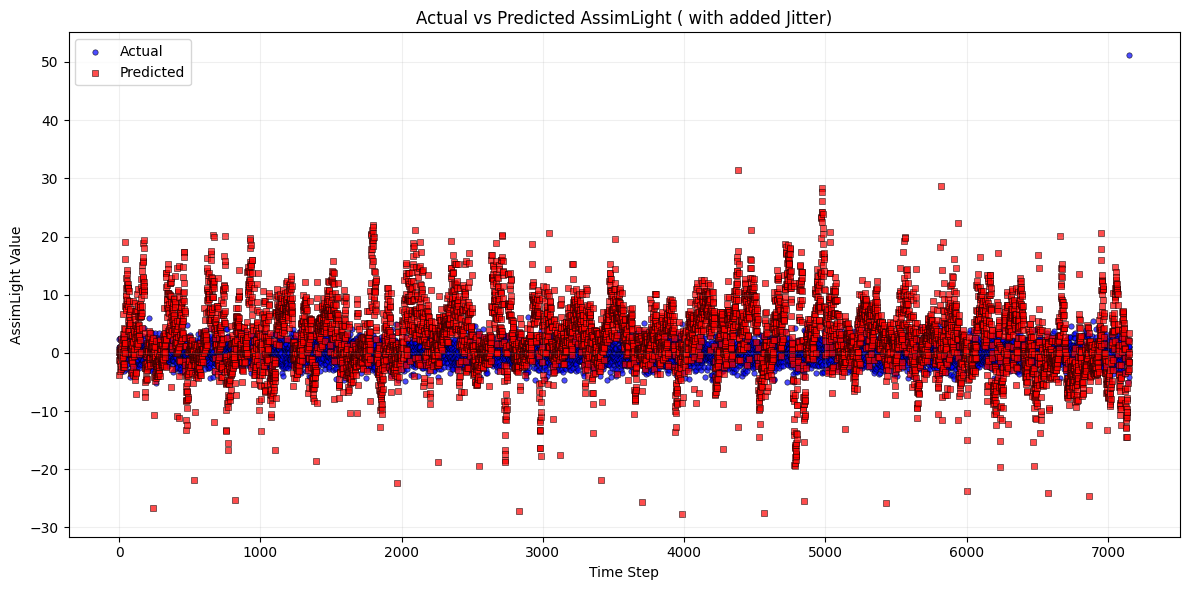

In [9]:
assimlight_idx = testData.columns.get_loc('AssimLight') 

np.random.seed(42)

plt.figure(figsize=(12, 6))

value_range = np.max(y_test_original[:, assimlight_idx]) - np.min(y_test_original[:, assimlight_idx])
jitter_amount = value_range * 0.03  

x_offset = 0.2  
actual_jittered = y_test_original[:, assimlight_idx] + np.random.normal(0, jitter_amount, size=len(y_test_original))
predicted_jittered = test_predictions_original[:, assimlight_idx] + np.random.normal(0, jitter_amount, size=len(test_predictions_original))

x_actual = np.arange(len(actual_jittered)) - x_offset + np.random.normal(0, 0.1, len(actual_jittered))
x_predicted = np.arange(len(predicted_jittered)) + x_offset + np.random.normal(0, 0.1, len(predicted_jittered))

plt.scatter(x_actual, actual_jittered, alpha=0.7, label='Actual', s=15, 
            color='blue', edgecolor='black', linewidth=0.5)
plt.scatter(x_predicted, predicted_jittered, alpha=0.7, label='Predicted', s=15, 
            color='red', marker='s', edgecolor='black', linewidth=0.5)

plt.title('Actual vs Predicted AssimLight ( with added Jitter)')
plt.legend()
plt.ylabel('AssimLight Value')
plt.xlabel('Time Step')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


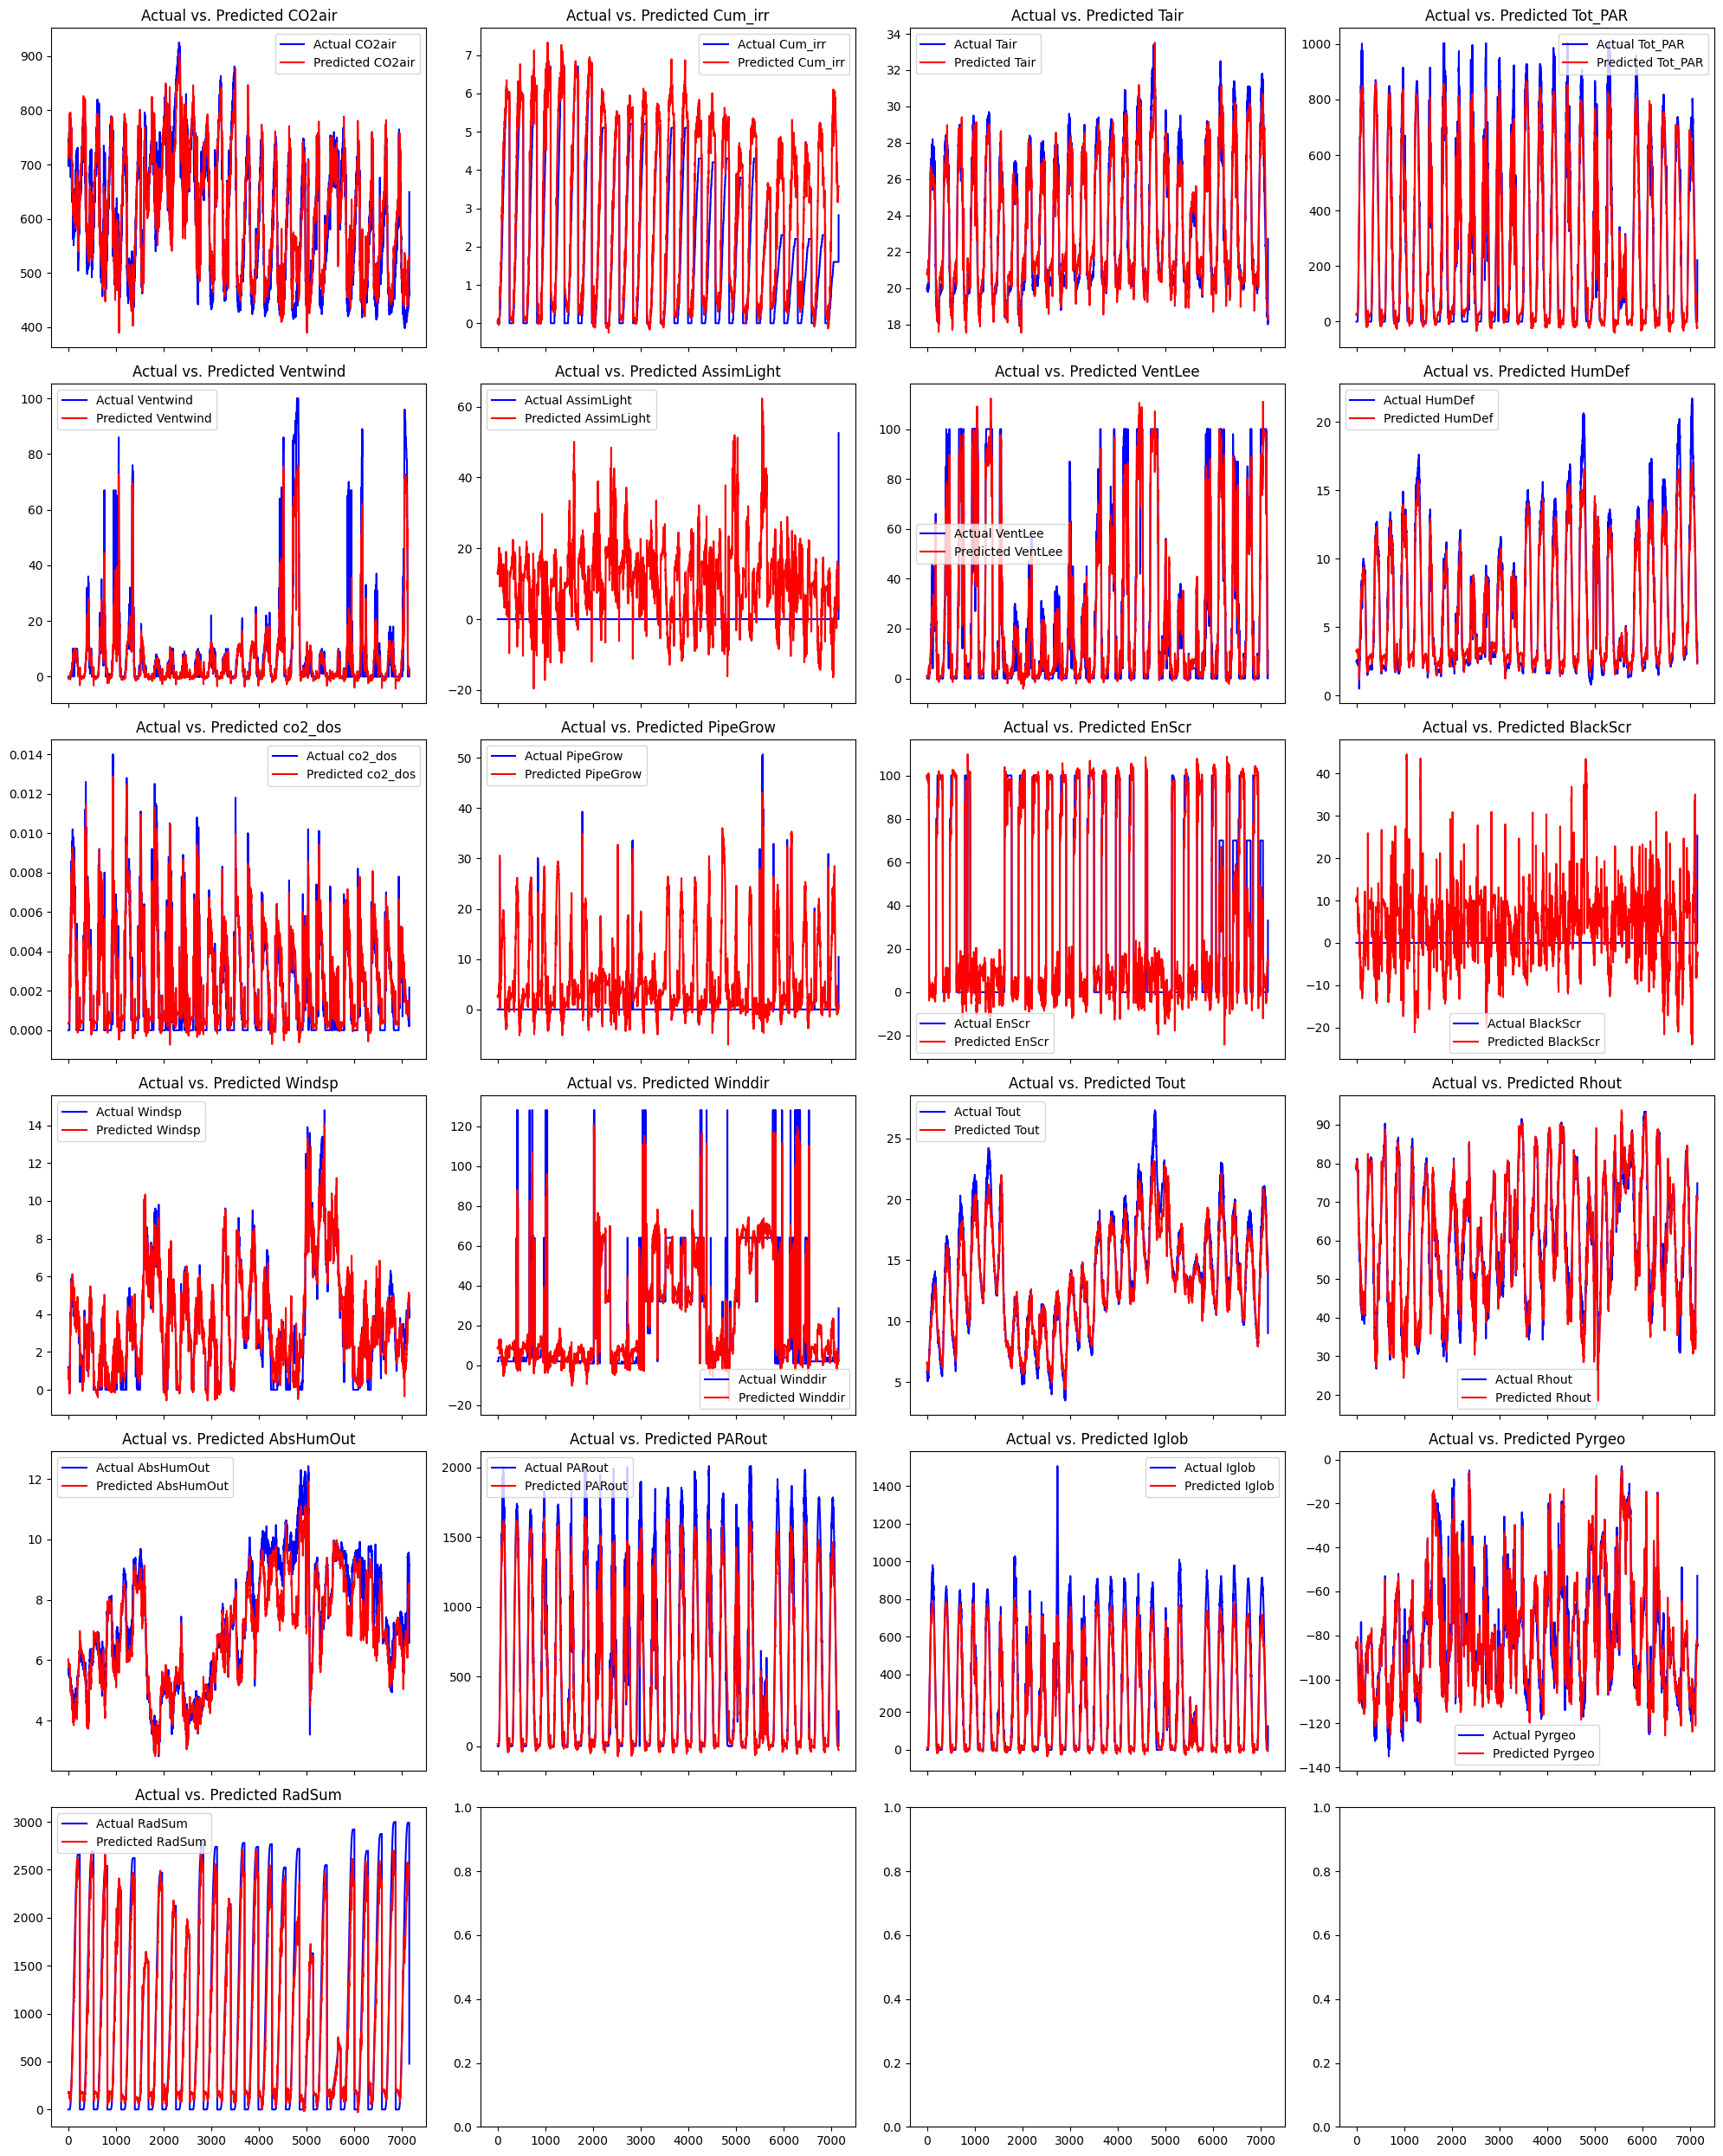

In [7]:
# From above - produces much less loss - slightly more accurate results
# Function to inverse transform predictions
def inverse_transform_predictions(predictions, scaler):
    return scaler.inverse_transform(predictions)

# Make predictions
test_predictions = model.predict(X_test)

y_test_original   = inverse_transform_predictions(y_test, target_scaler)

test_predictions_original  = inverse_transform_predictions(test_predictions, target_scaler)

# Load the best model
model = keras.models.load_model('checkpoint/model.keras')

# Make predictions on the test set
test_predictions = model.predict(X_test)

# Inverse transform the predictions and actual values to their original scale
test_predictions_original = target_scaler.inverse_transform(test_predictions)
y_test_original = target_scaler.inverse_transform(y_test)

# Define target names for labeling the plots
target_names = testData.columns.tolist()

# Plot actual vs. predicted for all targets
fig, axs = plt.subplots(nrows=6, ncols=4, figsize=(20, 25), sharex=True) # Adjust the subplot grid
axs = axs.flatten()  # Flatten the array of axes for easy iteration

for i in range(21):
    axs[i].plot(y_test_original[:, i], label=f'Actual {target_names[i]}', color='blue')
    axs[i].plot(test_predictions_original[:, i], label=f'Predicted {target_names[i]}', color='red')
    axs[i].set_title(f'Actual vs. Predicted {target_names[i]}')
    axs[i].legend(loc='best')

plt.tight_layout()
plt.show()